# (Stock) Index Creation and Analysis

## Data Import, Visualization & Normalization

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
plt.style.use("seaborn-v0_8")
pd.options.display.float_format = '{:.2f}'.format

In [2]:
stocks = yf.download(["AMZN", "BA", "DIS", "IBM", "KO", "MSFT"], 
                     start = "2014-01-01", end = "2018-12-31")

C:\Users\arsh\AppData\Local\Temp\ipykernel_9256\2331970428.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stocks = yf.download(["AMZN", "BA", "DIS", "IBM", "KO", "MSFT"],
[*********************100%***********************]  6 of 6 completed


In [3]:
stocks.head()

Price      Close                                  High                      \
Ticker      AMZN     BA   DIS    IBM    KO  MSFT  AMZN     BA   DIS    IBM   
Date                                                                         
2014-01-02 19.90 116.81 69.04 110.28 28.31 30.94 19.97 117.30 69.25 111.39   
2014-01-03 19.82 117.62 68.90 110.94 28.17 30.73 20.14 118.37 69.43 111.36   
2014-01-06 19.68 118.30 68.63 110.55 28.04 30.08 19.85 119.45 69.56 111.36   
2014-01-07 19.90 120.09 69.10 112.76 28.12 30.32 19.92 120.59 69.43 113.14   
2014-01-08 20.10 120.35 68.09 111.73 27.81 29.77 20.15 120.85 69.05 112.59   

Price       ...  Open                       Volume                     \
Ticker      ...   DIS    IBM    KO  MSFT      AMZN       BA       DIS   
Date        ...                                                         
2014-01-02  ... 68.83 111.27 28.63 31.10  42756000  3366700   5200900   
2014-01-03  ... 69.07 110.45 28.33 30.97  44204000  3177400   4060700   
2014-01-06  ... 69.28 111.24 28.19 30.68  63412000  4196500   6816200   
2014-01-07  ... 68.91 110.79 28.19 30.25  38320000  4238500   4494900   
2014-01-08  ... 68.91 112.53 28.16 29.97  46330000  4236100  10900300   

Price                                    
Ticker          IBM        KO      MSFT  
Date                                     
2014-01-02  4755639  12698600  30632200  
2014-01-03  4250107  10403400  31134800  
2014-01-06  4254919  11036300  43603700  
2014-01-07  6205186  11872300  35802800  
2014-01-08  4815470  15339600  59971700  

[5 rows x 30 columns]

In [4]:
stocks.tail()

Price      Close                                  High                      \
Ticker      AMZN     BA    DIS   IBM    KO  MSFT  AMZN     BA    DIS   IBM   
Date                                                                         
2018-12-21 68.87 295.93 101.27 78.62 38.92 92.23 74.00 306.06 105.68 81.69   
2018-12-24 67.20 285.83  97.51 76.23 37.61 88.38 69.80 294.42 100.96 78.66   
2018-12-26 73.54 305.04 102.84 78.93 38.41 94.42 73.66 305.20 102.86 78.93   
2018-12-27 73.08 308.16 103.51 80.63 38.89 95.00 73.45 308.16 103.54 80.63   
2018-12-28 73.90 307.43 104.27 80.10 38.62 94.26 75.67 312.43 105.45 81.35   

Price       ...   Open                       Volume                     \
Ticker      ...    DIS   IBM    KO  MSFT       AMZN       BA       DIS   
Date        ...                                                          
2018-12-21  ... 103.46 79.72 38.67 95.42  272806000  7641700  15530600   
2018-12-24  ... 100.31 77.88 38.96 91.72  144400000  3435300   7133000   
2018-12-26  ...  97.65 76.53 37.54 89.33  208236000  4843400   9422800   
2018-12-27  ... 101.46 77.94 38.24 93.24  194440000  4341100   8201400   
2018-12-28  ... 104.25 80.94 39.18 95.86  176580000  3725200   7620500   

Price                                      
Ticker           IBM        KO       MSFT  
Date                                       
2018-12-21  10864279  32477700  111242100  
2018-12-24   3997184  10733700   43935200  
2018-12-26   6951507  14342600   51634800  
2018-12-27   6323698  16966500   49498500  
2018-12-28   5352905  13218200   38196300  

[5 rows x 30 columns]

In [5]:
stocks.to_csv("index_stocks.csv")

In [6]:
stocks = pd.read_csv("index_stocks.csv", header = [0,1], index_col = [0], parse_dates = [0]).Close

In [7]:
stocks

Ticker,AMZN,BA,DIS,IBM,KO,MSFT
Date,,,,,,
2014-01-02,19.90,116.81,69.04,110.28,28.31,30.94
2014-01-03,19.82,117.62,68.90,110.94,28.17,30.73
2014-01-06,19.68,118.30,68.63,110.55,28.04,30.08
2014-01-07,19.90,120.09,69.10,112.76,28.12,30.32
2014-01-08,20.10,120.35,68.09,111.73,27.81,29.77
...,...,...,...,...,...,...
2018-12-21,68.87,295.93,101.27,78.62,38.92,92.23
2018-12-24,67.20,285.83,97.51,76.23,37.61,88.38
2018-12-26,73.54,305.04,102.84,78.93,38.41,94.42


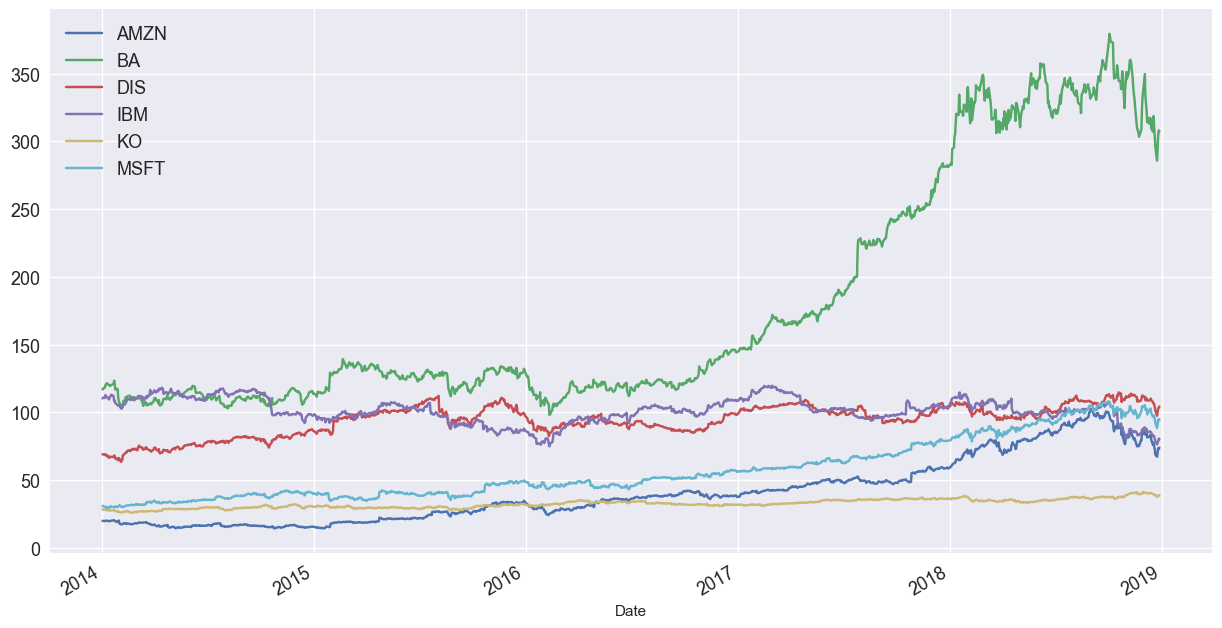

In [8]:
stocks.plot(figsize = (15, 8 ), fontsize = 13)
plt.legend(fontsize = 13)
plt.show()

In [9]:
norm = stocks.div(stocks.iloc[0]).mul(100)
norm

Ticker,AMZN,BA,DIS,IBM,KO,MSFT
Date,,,,,,
2014-01-02,100.00,100.00,100.00,100.00,100.00,100.00
2014-01-03,99.62,100.70,99.79,100.60,99.51,99.33
2014-01-06,98.91,101.27,99.41,100.25,99.04,97.23
2014-01-07,100.02,102.81,100.09,102.25,99.34,97.98
2014-01-08,100.99,103.04,98.62,101.32,98.23,96.23
...,...,...,...,...,...,...
2018-12-21,346.12,253.35,146.68,71.29,137.48,298.10
2018-12-24,337.70,244.70,141.24,69.12,132.82,285.66
2018-12-26,369.60,261.15,148.95,71.58,135.65,305.17


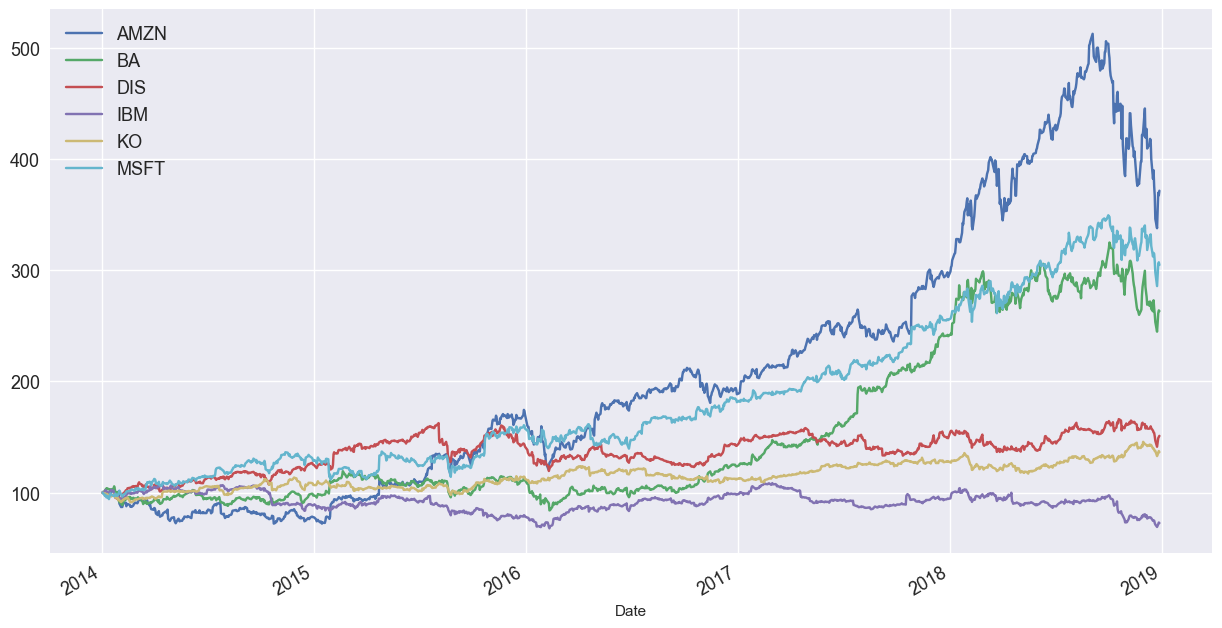

In [10]:
norm.plot(figsize = (15, 8), fontsize = 13)
plt.legend(fontsize = 13)
plt.show()

## Creating a Price-weighted Index

In [11]:
stocks.head()

Ticker,AMZN,BA,DIS,IBM,KO,MSFT
Date,,,,,,
2014-01-02,19.90,116.81,69.04,110.28,28.31,30.94
2014-01-03,19.82,117.62,68.90,110.94,28.17,30.73
2014-01-06,19.68,118.30,68.63,110.55,28.04,30.08
2014-01-07,19.90,120.09,69.10,112.76,28.12,30.32
2014-01-08,20.10,120.35,68.09,111.73,27.81,29.77


In [12]:
norm.head()

Ticker,AMZN,BA,DIS,IBM,KO,MSFT
Date,,,,,,
2014-01-02,100.00,100.00,100.00,100.00,100.00,100.00
2014-01-03,99.62,100.70,99.79,100.60,99.51,99.33
2014-01-06,98.91,101.27,99.41,100.25,99.04,97.23
2014-01-07,100.02,102.81,100.09,102.25,99.34,97.98
2014-01-08,100.99,103.04,98.62,101.32,98.23,96.23


In [13]:
stocks.sum(axis = 1).iloc[0] #updated

375.27551460266113

In [14]:
stocks.sum(axis = 1).div(stocks.sum(axis = 1).iloc[0]).mul(100) #updated

Date
2014-01-02   100.00
2014-01-03   100.24
2014-01-06   100.00
2014-01-07   101.34
2014-01-08   100.69
              ...  
2018-12-21   180.09
2018-12-24   173.94
2018-12-26   184.71
2018-12-27   186.34
2018-12-28   186.15
Length: 1257, dtype: float64

In [15]:
norm["PWI"] = stocks.sum(axis = 1).div(stocks.sum(axis = 1).iloc[0]).mul(100) #updated

In [16]:
norm.head()

Ticker,AMZN,BA,DIS,IBM,KO,MSFT,PWI
Date,,,,,,,
2014-01-02,100.00,100.00,100.00,100.00,100.00,100.00,100.00
2014-01-03,99.62,100.70,99.79,100.60,99.51,99.33,100.24
2014-01-06,98.91,101.27,99.41,100.25,99.04,97.23,100.00
2014-01-07,100.02,102.81,100.09,102.25,99.34,97.98,101.34
2014-01-08,100.99,103.04,98.62,101.32,98.23,96.23,100.69


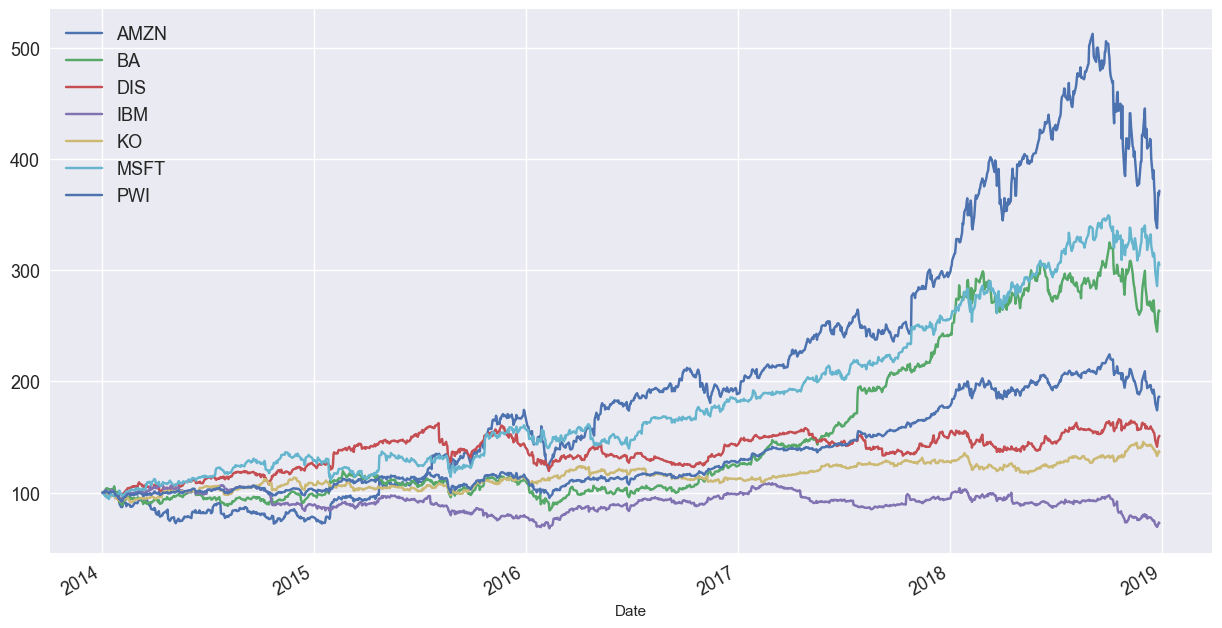

In [17]:
norm.plot(figsize = (15, 8 ), fontsize = 13)
plt.legend(fontsize = 13)
plt.show()

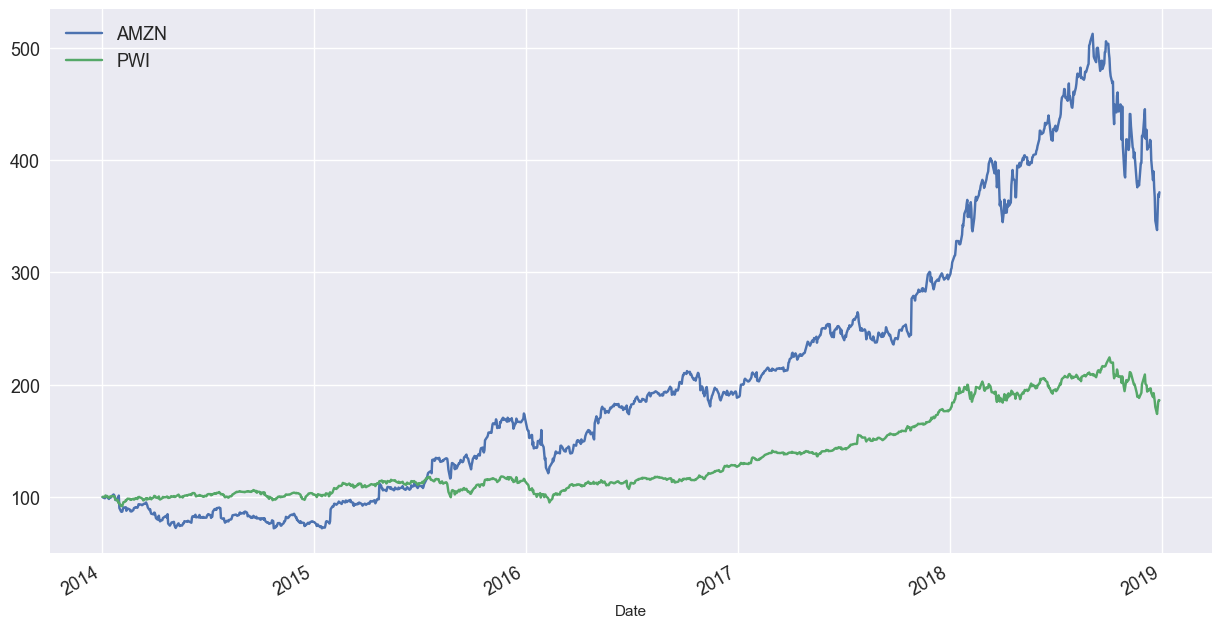

In [18]:
norm.loc[:, ["AMZN", "PWI"]].plot(figsize = (15, 8 ), fontsize = 13)
plt.legend(fontsize = 13)
plt.show()

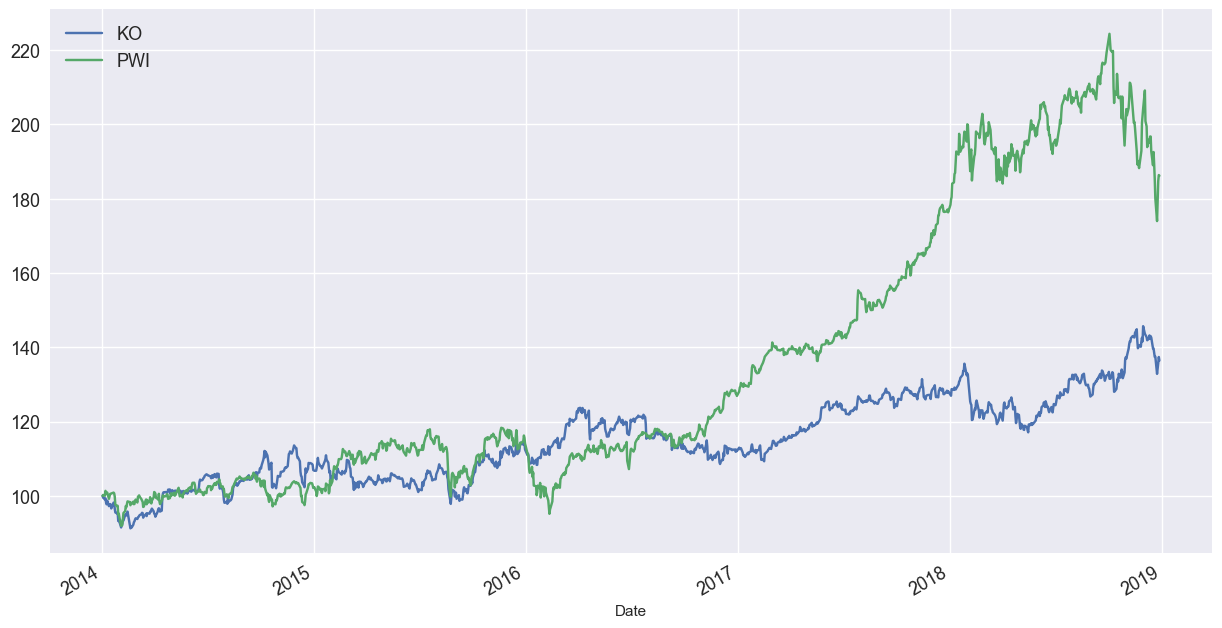

In [19]:
norm.loc[:, ["KO", "PWI"]].plot(figsize = (15, 8 ), fontsize = 13)
plt.legend(fontsize = 13)
plt.show()

In [20]:
stocks.head()

Ticker,AMZN,BA,DIS,IBM,KO,MSFT
Date,,,,,,
2014-01-02,19.90,116.81,69.04,110.28,28.31,30.94
2014-01-03,19.82,117.62,68.90,110.94,28.17,30.73
2014-01-06,19.68,118.30,68.63,110.55,28.04,30.08
2014-01-07,19.90,120.09,69.10,112.76,28.12,30.32
2014-01-08,20.10,120.35,68.09,111.73,27.81,29.77


In [21]:
stocks.div(stocks.sum(axis = 1), axis = "rows")

Ticker,AMZN,BA,DIS,IBM,KO,MSFT
Date,,,,,,
2014-01-02,0.05,0.31,0.18,0.29,0.08,0.08
2014-01-03,0.05,0.31,0.18,0.29,0.07,0.08
2014-01-06,0.05,0.32,0.18,0.29,0.07,0.08
2014-01-07,0.05,0.32,0.18,0.30,0.07,0.08
2014-01-08,0.05,0.32,0.18,0.30,0.07,0.08
...,...,...,...,...,...,...
2018-12-21,0.10,0.44,0.15,0.12,0.06,0.14
2018-12-24,0.10,0.44,0.15,0.12,0.06,0.14
2018-12-26,0.11,0.44,0.15,0.11,0.06,0.14


In [22]:
weights_PWI = stocks.div(stocks.sum(axis = 1), axis = "rows")

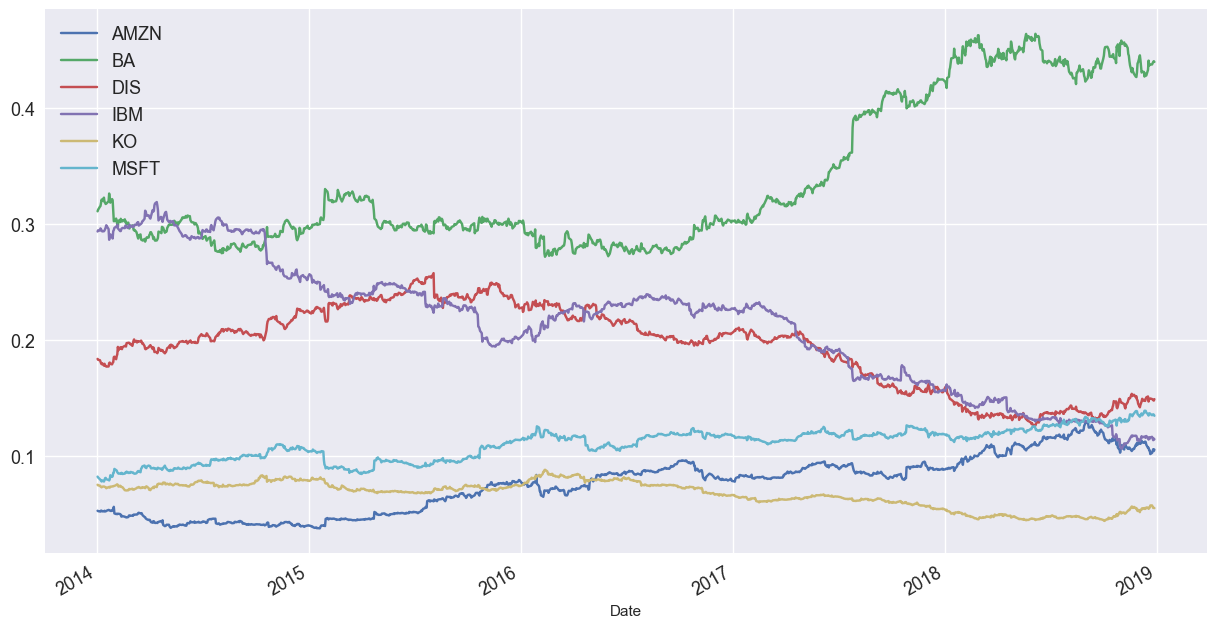

In [23]:
weights_PWI.plot(figsize = (15, 8), fontsize = 13)
plt.legend(fontsize = 13)
plt.show()

## Creating an Equal-weighted Index

In [24]:
stocks.head()

Ticker,AMZN,BA,DIS,IBM,KO,MSFT
Date,,,,,,
2014-01-02,19.90,116.81,69.04,110.28,28.31,30.94
2014-01-03,19.82,117.62,68.90,110.94,28.17,30.73
2014-01-06,19.68,118.30,68.63,110.55,28.04,30.08
2014-01-07,19.90,120.09,69.10,112.76,28.12,30.32
2014-01-08,20.10,120.35,68.09,111.73,27.81,29.77


In [25]:
norm.head()

Ticker,AMZN,BA,DIS,IBM,KO,MSFT,PWI
Date,,,,,,,
2014-01-02,100.00,100.00,100.00,100.00,100.00,100.00,100.00
2014-01-03,99.62,100.70,99.79,100.60,99.51,99.33,100.24
2014-01-06,98.91,101.27,99.41,100.25,99.04,97.23,100.00
2014-01-07,100.02,102.81,100.09,102.25,99.34,97.98,101.34
2014-01-08,100.99,103.04,98.62,101.32,98.23,96.23,100.69


In [26]:
ret = stocks.pct_change().dropna()

In [27]:
ret.head()

Ticker,AMZN,BA,DIS,IBM,KO,MSFT
Date,,,,,,
2014-01-03,-0.00,0.01,-0.00,0.01,-0.00,-0.01
2014-01-06,-0.01,0.01,-0.00,-0.00,-0.00,-0.02
2014-01-07,0.01,0.02,0.01,0.02,0.00,0.01
2014-01-08,0.01,0.00,-0.01,-0.01,-0.01,-0.02
2014-01-09,-0.00,0.01,-0.00,-0.00,-0.01,-0.01


In [28]:
ret["Mean_ret"] = ret.mean(axis = 1)

In [29]:
ret.head()

Ticker,AMZN,BA,DIS,IBM,KO,MSFT,Mean_ret
Date,,,,,,,
2014-01-03,-0.00,0.01,-0.00,0.01,-0.00,-0.01,-0.00
2014-01-06,-0.01,0.01,-0.00,-0.00,-0.00,-0.02,-0.01
2014-01-07,0.01,0.02,0.01,0.02,0.00,0.01,0.01
2014-01-08,0.01,0.00,-0.01,-0.01,-0.01,-0.02,-0.01
2014-01-09,-0.00,0.01,-0.00,-0.00,-0.01,-0.01,-0.00


In [30]:
norm["EWI"] = 100

In [31]:
norm.head()

Ticker,AMZN,BA,DIS,IBM,KO,MSFT,PWI,EWI
Date,,,,,,,,
2014-01-02,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100
2014-01-03,99.62,100.70,99.79,100.60,99.51,99.33,100.24,100
2014-01-06,98.91,101.27,99.41,100.25,99.04,97.23,100.00,100
2014-01-07,100.02,102.81,100.09,102.25,99.34,97.98,101.34,100
2014-01-08,100.99,103.04,98.62,101.32,98.23,96.23,100.69,100


In [32]:
ret.Mean_ret.add(1).cumprod().mul(100)

Date
2014-01-03    99.92
2014-01-06    99.35
2014-01-07   100.41
2014-01-08    99.72
2014-01-09    99.52
              ...  
2018-12-21   195.55
2018-12-24   188.98
2018-12-26   199.73
2018-12-27   201.42
2018-12-28   201.25
Name: Mean_ret, Length: 1256, dtype: float64

In [33]:
norm.iloc[1:, -1] = ret.Mean_ret.add(1).cumprod().mul(100)

C:\Users\arsh\AppData\Local\Temp\ipykernel_9256\3956271052.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 99.92243105  99.34929366 100.40710427 ... 199.73429504 201.42008273
 201.24520115]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  norm.iloc[1:, -1] = ret.Mean_ret.add(1).cumprod().mul(100)


In [34]:
norm

Ticker,AMZN,BA,DIS,IBM,KO,MSFT,PWI,EWI
Date,,,,,,,,
2014-01-02,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00
2014-01-03,99.62,100.70,99.79,100.60,99.51,99.33,100.24,99.92
2014-01-06,98.91,101.27,99.41,100.25,99.04,97.23,100.00,99.35
2014-01-07,100.02,102.81,100.09,102.25,99.34,97.98,101.34,100.41
2014-01-08,100.99,103.04,98.62,101.32,98.23,96.23,100.69,99.72
...,...,...,...,...,...,...,...,...
2018-12-21,346.12,253.35,146.68,71.29,137.48,298.10,180.09,195.55
2018-12-24,337.70,244.70,141.24,69.12,132.82,285.66,173.94,188.98
2018-12-26,369.60,261.15,148.95,71.58,135.65,305.17,184.71,199.73


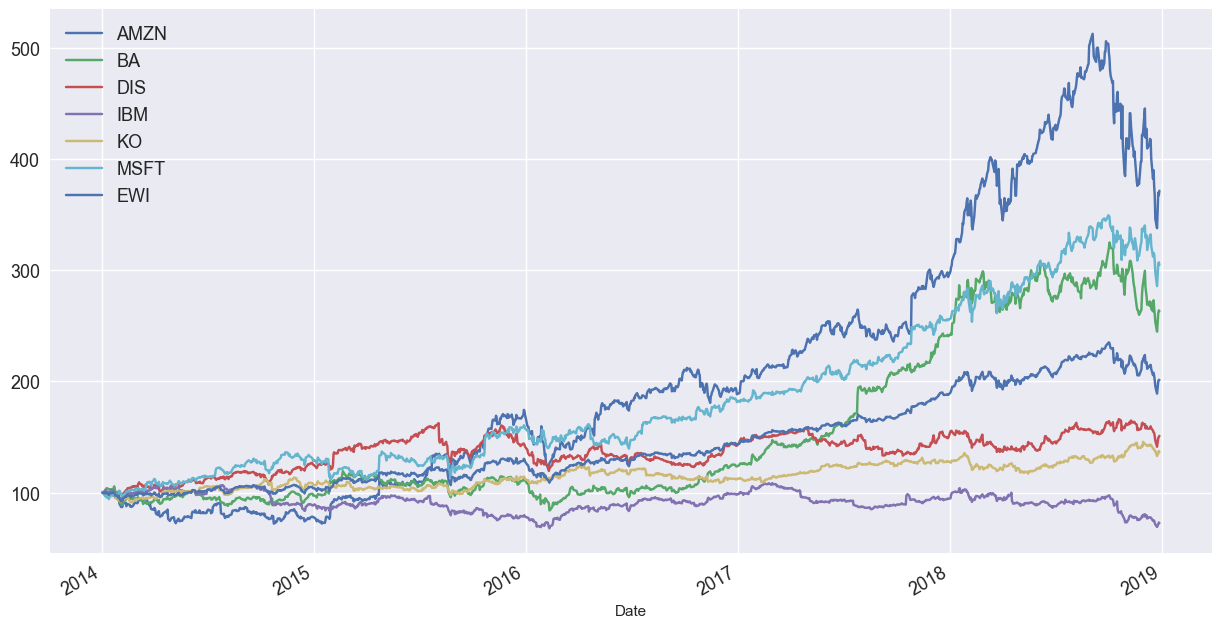

In [35]:
norm.iloc[:, [0, 1, 2, 3, 4, 5, 7]].plot(figsize = (15, 8 ), fontsize = 13)
plt.legend(fontsize = 13)
plt.show()

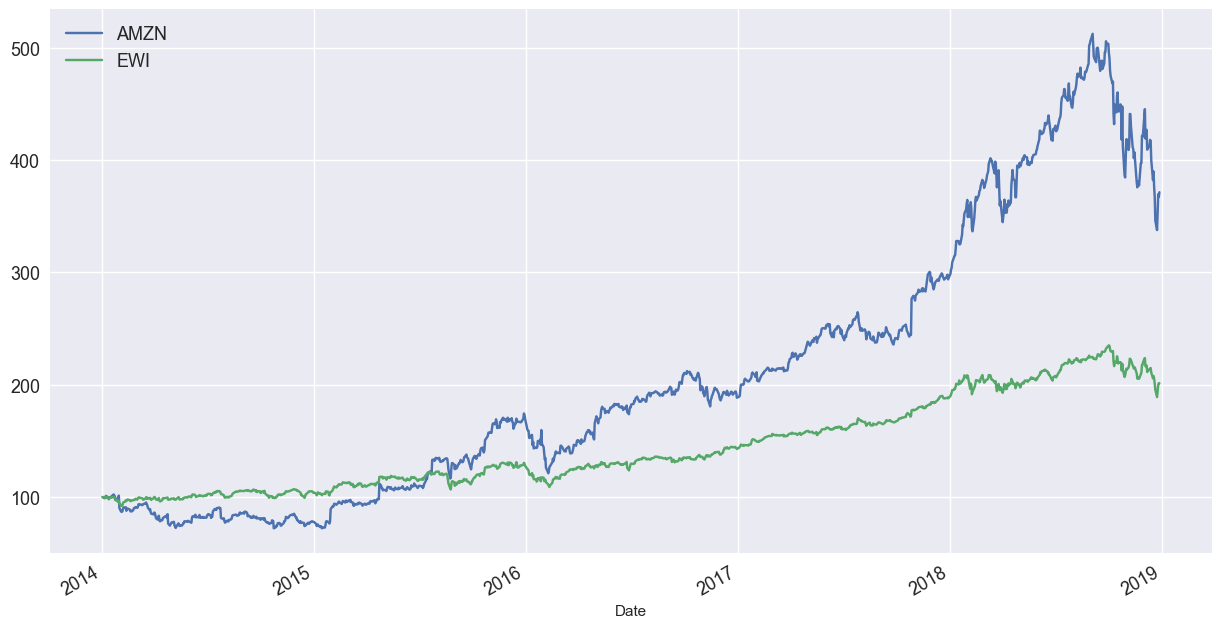

In [36]:
norm.loc[:, ["AMZN", "EWI"]].plot(figsize = (15, 8 ), fontsize = 13)
plt.legend(fontsize = 13)
plt.show()

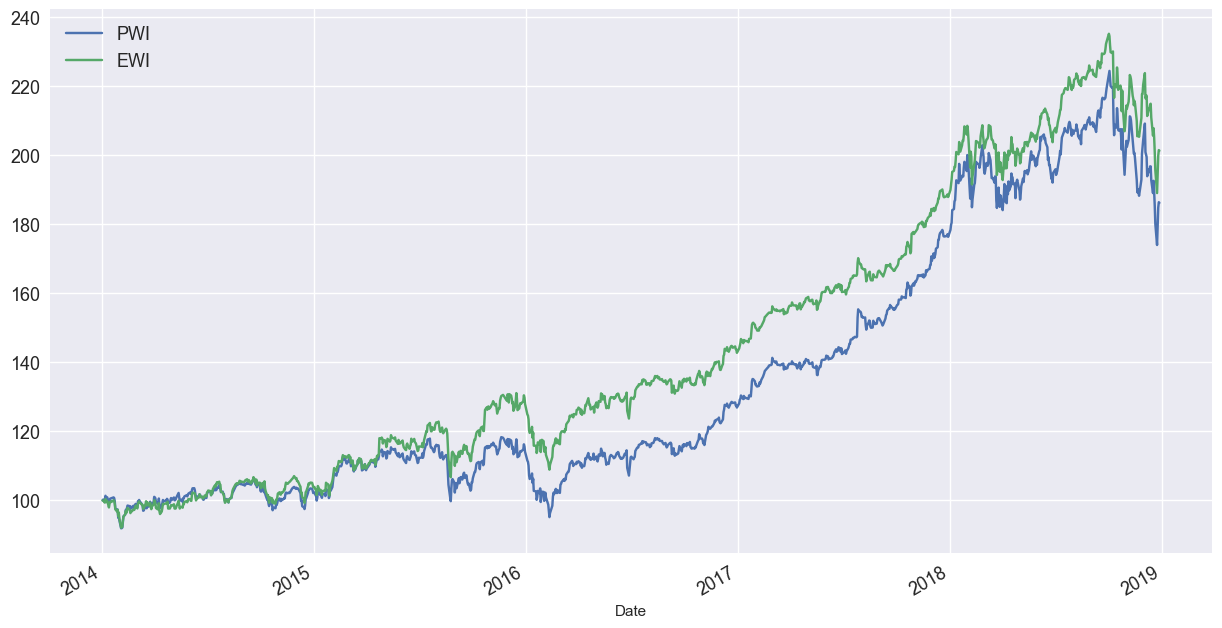

In [37]:
norm.iloc[:, -2:].plot(figsize = (15, 8 ), fontsize = 13)
plt.legend(fontsize = 13)
plt.show()

In [38]:
weights_EWI = stocks.copy()

In [39]:
weights_EWI.iloc[:,:] = (1/6)

In [40]:
weights_EWI

Ticker,AMZN,BA,DIS,IBM,KO,MSFT
Date,,,,,,
2014-01-02,0.17,0.17,0.17,0.17,0.17,0.17
2014-01-03,0.17,0.17,0.17,0.17,0.17,0.17
2014-01-06,0.17,0.17,0.17,0.17,0.17,0.17
2014-01-07,0.17,0.17,0.17,0.17,0.17,0.17
2014-01-08,0.17,0.17,0.17,0.17,0.17,0.17
...,...,...,...,...,...,...
2018-12-21,0.17,0.17,0.17,0.17,0.17,0.17
2018-12-24,0.17,0.17,0.17,0.17,0.17,0.17
2018-12-26,0.17,0.17,0.17,0.17,0.17,0.17


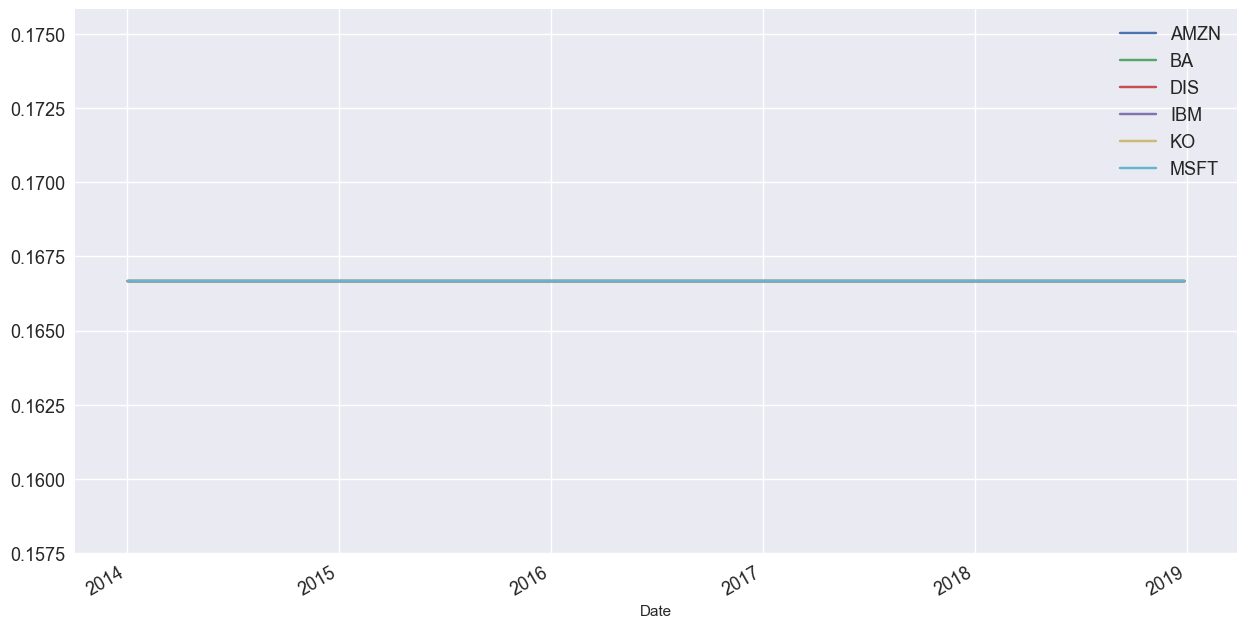

In [41]:
weights_EWI.plot(figsize = (15, 8), fontsize = 13)
plt.legend(fontsize = 13)
plt.show()

## Creating a Value-weighted Index (Part 1)

In [42]:
stocks.head()

Ticker,AMZN,BA,DIS,IBM,KO,MSFT
Date,,,,,,
2014-01-02,19.90,116.81,69.04,110.28,28.31,30.94
2014-01-03,19.82,117.62,68.90,110.94,28.17,30.73
2014-01-06,19.68,118.30,68.63,110.55,28.04,30.08
2014-01-07,19.90,120.09,69.10,112.76,28.12,30.32
2014-01-08,20.10,120.35,68.09,111.73,27.81,29.77


In [43]:
norm.head()

Ticker,AMZN,BA,DIS,IBM,KO,MSFT,PWI,EWI
Date,,,,,,,,
2014-01-02,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00
2014-01-03,99.62,100.70,99.79,100.60,99.51,99.33,100.24,99.92
2014-01-06,98.91,101.27,99.41,100.25,99.04,97.23,100.00,99.35
2014-01-07,100.02,102.81,100.09,102.25,99.34,97.98,101.34,100.41
2014-01-08,100.99,103.04,98.62,101.32,98.23,96.23,100.69,99.72


In [44]:
listings = pd.read_csv("listings_clean.csv")

In [45]:
listings.head()

,Symbol,Exchange,Name,Last_Price,Market_Cap,IPO_Year,Sector,Industry
0,A,NYSE,"Agilent Technologies, Inc.",81.68,25934696179.92,1999,Capital Goods,Biotechnology: Laboratory Analytical Instruments
1,AA,NYSE,Alcoa Corporation,29.15,5407809589.60,2016,Basic Industries,Aluminum
2,AABA,NASDAQ,Altaba Inc.,75.39,42781131315.30,1969,Technology,EDP Services
3,AAC,NYSE,"AAC Holdings, Inc.",2.16,53141086.80,2014,Health Care,Medical Specialities
4,AAL,NASDAQ,"American Airlines Group, Inc.",34.02,15276869742.96,1969,Transportation,Air Freight/Delivery Services


In [46]:
listings.tail()

,Symbol,Exchange,Name,Last_Price,Market_Cap,IPO_Year,Sector,Industry
6847,ZUMZ,NASDAQ,Zumiez Inc.,26.72,681919062.56,2005,Consumer Services,Clothing/Shoe/Accessory Stores
6848,ZUO,NYSE,"Zuora, Inc.",19.79,2147266454.00,2018,Technology,Computer Software: Prepackaged Software
6849,ZYME,NYSE,Zymeworks Inc.,15.74,504078206.26,2017,Health Care,Major Pharmaceuticals
6850,ZYNE,NASDAQ,"Zynerba Pharmaceuticals, Inc.",7.85,165399468.60,2015,Health Care,Major Pharmaceuticals
6851,ZYXI,NASDAQ,"Zynex, Inc.",5.02,161834880.48,1969,Health Care,Biotechnology: Electromedical & Electrotherape...


In [47]:
listings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6852 entries, 0 to 6851
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Symbol      6852 non-null   object 
 1   Exchange    6852 non-null   object 
 2   Name        6852 non-null   object 
 3   Last_Price  6852 non-null   float64
 4   Market_Cap  5954 non-null   float64
 5   IPO_Year    6852 non-null   int64  
 6   Sector      5309 non-null   object 
 7   Industry    5309 non-null   object 
dtypes: float64(2), int64(1), object(5)
memory usage: 428.4+ KB


In [48]:
listings.set_index("Symbol", inplace = True)

In [49]:
listings.head()

,Exchange,Name,Last_Price,Market_Cap,IPO_Year,Sector,Industry
Symbol,,,,,,,
A,NYSE,"Agilent Technologies, Inc.",81.68,25934696179.92,1999,Capital Goods,Biotechnology: Laboratory Analytical Instruments
AA,NYSE,Alcoa Corporation,29.15,5407809589.60,2016,Basic Industries,Aluminum
AABA,NASDAQ,Altaba Inc.,75.39,42781131315.30,1969,Technology,EDP Services
AAC,NYSE,"AAC Holdings, Inc.",2.16,53141086.80,2014,Health Care,Medical Specialities
AAL,NASDAQ,"American Airlines Group, Inc.",34.02,15276869742.96,1969,Transportation,Air Freight/Delivery Services


In [50]:
ticker = ["AMZN", "BA", "DIS", "IBM", "KO", "MSFT"]

In [51]:
listings = listings.loc[ticker, ["Last_Price", "Market_Cap"]]

In [52]:
listings

,Last_Price,Market_Cap
Symbol,,
AMZN,1847.33,907413834783.70
BA,364.94,206002047212.28
DIS,117.16,210609322989.68
IBM,143.02,127268671933.12
KO,46.64,199393520886.56
MSFT,120.19,922123334074.74


In [53]:
listings.Market_Cap.div(listings.Last_Price)

Symbol
AMZN    491202890.00
BA      564481962.00
DIS    1797621398.00
IBM     889866256.00
KO     4275161254.00
MSFT   7672213446.00
dtype: float64

In [54]:
listings["Shares"] = listings.Market_Cap.div(listings.Last_Price)

In [55]:
listings

,Last_Price,Market_Cap,Shares
Symbol,,,
AMZN,1847.33,907413834783.70,491202890.00
BA,364.94,206002047212.28,564481962.00
DIS,117.16,210609322989.68,1797621398.00
IBM,143.02,127268671933.12,889866256.00
KO,46.64,199393520886.56,4275161254.00
MSFT,120.19,922123334074.74,7672213446.00


In [56]:
stocks.head()

Ticker,AMZN,BA,DIS,IBM,KO,MSFT
Date,,,,,,
2014-01-02,19.90,116.81,69.04,110.28,28.31,30.94
2014-01-03,19.82,117.62,68.90,110.94,28.17,30.73
2014-01-06,19.68,118.30,68.63,110.55,28.04,30.08
2014-01-07,19.90,120.09,69.10,112.76,28.12,30.32
2014-01-08,20.10,120.35,68.09,111.73,27.81,29.77


In [57]:
stocks.tail()

Ticker,AMZN,BA,DIS,IBM,KO,MSFT
Date,,,,,,
2018-12-21,68.87,295.93,101.27,78.62,38.92,92.23
2018-12-24,67.20,285.83,97.51,76.23,37.61,88.38
2018-12-26,73.54,305.04,102.84,78.93,38.41,94.42
2018-12-27,73.08,308.16,103.51,80.63,38.89,95.00
2018-12-28,73.90,307.43,104.27,80.10,38.62,94.26


In [58]:
mcap = stocks.mul(listings.Shares, axis = "columns")

In [59]:
mcap.head()

Ticker,AMZN,BA,DIS,IBM,KO,MSFT
Date,,,,,,
2014-01-02,9774200924.02,65935969499.42,124110525916.26,98130328616.98,121040812864.35,237375346765.89
2014-01-03,9736623932.92,66394305321.00,123850206002.36,98717433141.37,120445473045.10,235778339643.85
2014-01-06,9667609424.70,66775444341.06,123378308441.76,98378926583.72,119879855368.59,230795867074.34
2014-01-07,9775674660.11,67788572149.55,124224454451.37,100341232668.69,120237091877.03,232584442468.45
2014-01-08,9871213607.23,67938129378.36,122401954473.53,99420903538.16,118897467201.71,228432221024.41


In [60]:
mcap.tail()

Ticker,AMZN,BA,DIS,IBM,KO,MSFT
Date,,,,,,
2018-12-21,33830369842.30,167047297919.87,182051229725.20,69957118958.39,166401254885.40,707623490808.95
2018-12-24,33007850842.84,161348317799.12,175291113391.85,67832050013.15,160769426630.06,678087997725.48
2018-12-26,36125515645.63,172192287091.65,184863551568.40,70240871095.92,164197478276.30,724407979615.00
2018-12-27,35898089966.75,173953002938.02,186068832358.34,71747972082.94,166261361036.07,728874325612.39
2018-12-28,36300385253.58,173536135903.16,187431352904.50,71275033749.35,165107032923.59,723183441153.01


In [61]:
mcap.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1257 entries, 2014-01-02 to 2018-12-28
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AMZN    1257 non-null   float64
 1   BA      1257 non-null   float64
 2   DIS     1257 non-null   float64
 3   IBM     1257 non-null   float64
 4   KO      1257 non-null   float64
 5   MSFT    1257 non-null   float64
dtypes: float64(6)
memory usage: 68.7 KB


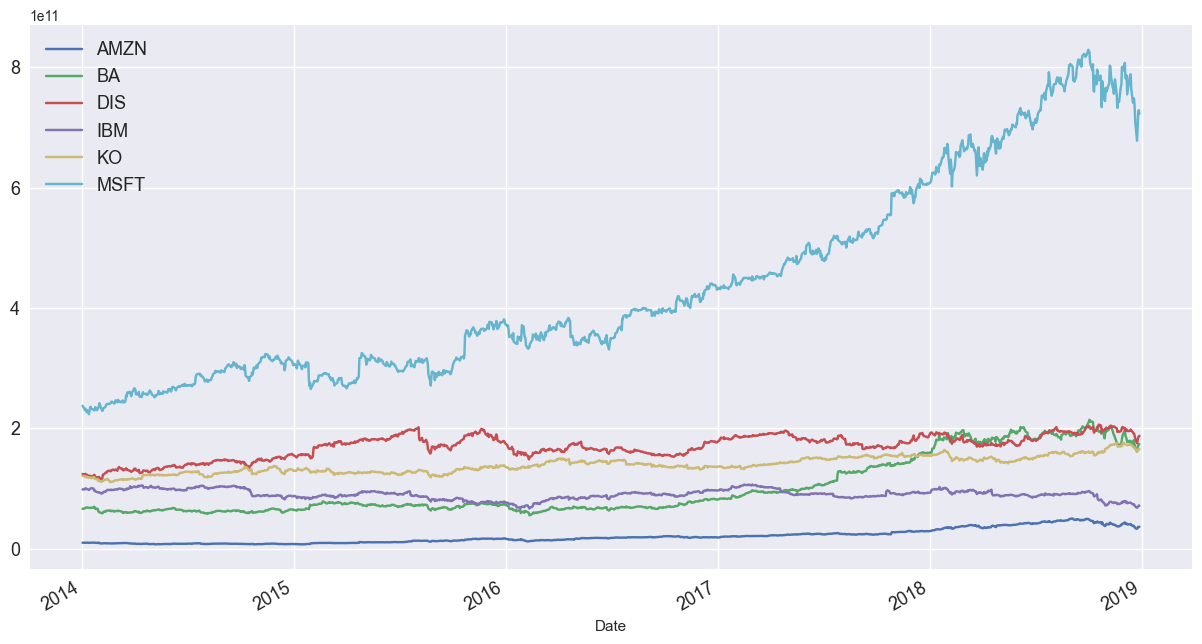

In [62]:
mcap.plot(figsize = (15, 8 ), fontsize = 13)
plt.legend(fontsize = 13)
plt.show()

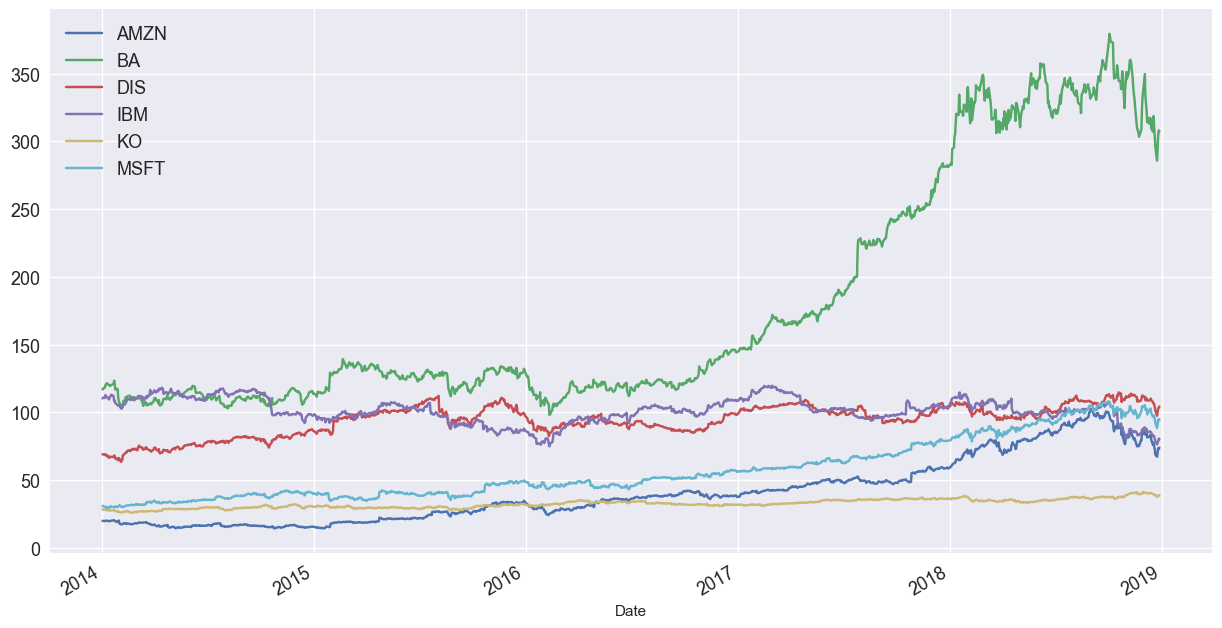

In [63]:
stocks.plot(figsize = (15, 8 ), fontsize = 13)
plt.legend(fontsize = 13)
plt.show()

## Creating a Value-weighted Index (Part 2)

In [64]:
mcap.head()

Ticker,AMZN,BA,DIS,IBM,KO,MSFT
Date,,,,,,
2014-01-02,9774200924.02,65935969499.42,124110525916.26,98130328616.98,121040812864.35,237375346765.89
2014-01-03,9736623932.92,66394305321.00,123850206002.36,98717433141.37,120445473045.10,235778339643.85
2014-01-06,9667609424.70,66775444341.06,123378308441.76,98378926583.72,119879855368.59,230795867074.34
2014-01-07,9775674660.11,67788572149.55,124224454451.37,100341232668.69,120237091877.03,232584442468.45
2014-01-08,9871213607.23,67938129378.36,122401954473.53,99420903538.16,118897467201.71,228432221024.41


In [65]:
mcap.sum(axis = 1)

Date
2014-01-02    656367184586.94
2014-01-03    654922381086.60
2014-01-06    648876011234.17
2014-01-07    654951468275.20
2014-01-08    646961889223.40
                   ...       
2018-12-21   1326910762140.11
2018-12-24   1276336756402.51
2018-12-26   1352027683292.89
2018-12-27   1362803583994.51
2018-12-28   1356833381887.19
Length: 1257, dtype: float64

In [66]:
mcap.div(mcap.sum(axis = 1), axis = "index")

Ticker,AMZN,BA,DIS,IBM,KO,MSFT
Date,,,,,,
2014-01-02,0.01,0.10,0.19,0.15,0.18,0.36
2014-01-03,0.01,0.10,0.19,0.15,0.18,0.36
2014-01-06,0.01,0.10,0.19,0.15,0.18,0.36
2014-01-07,0.01,0.10,0.19,0.15,0.18,0.36
2014-01-08,0.02,0.11,0.19,0.15,0.18,0.35
...,...,...,...,...,...,...
2018-12-21,0.03,0.13,0.14,0.05,0.13,0.53
2018-12-24,0.03,0.13,0.14,0.05,0.13,0.53
2018-12-26,0.03,0.13,0.14,0.05,0.12,0.54


In [67]:
weights_vwi = mcap.div(mcap.sum(axis = 1), axis = "index")

In [68]:
weights_vwi.tail()

Ticker,AMZN,BA,DIS,IBM,KO,MSFT
Date,,,,,,
2018-12-21,0.03,0.13,0.14,0.05,0.13,0.53
2018-12-24,0.03,0.13,0.14,0.05,0.13,0.53
2018-12-26,0.03,0.13,0.14,0.05,0.12,0.54
2018-12-27,0.03,0.13,0.14,0.05,0.12,0.53
2018-12-28,0.03,0.13,0.14,0.05,0.12,0.53


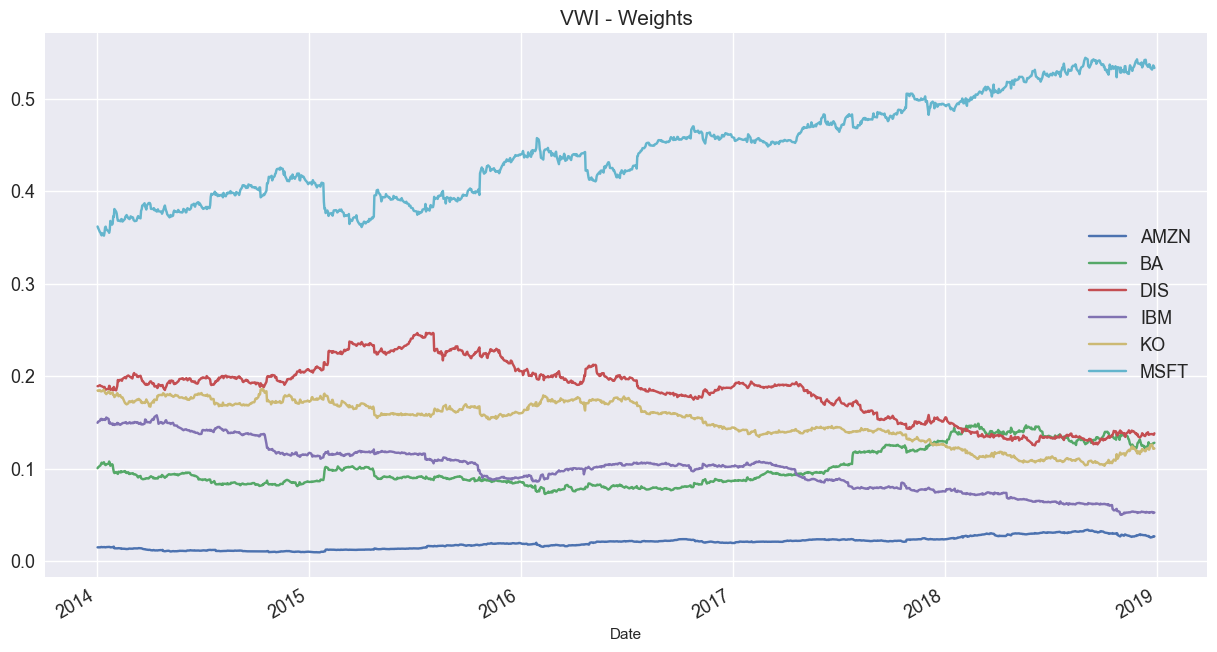

In [69]:
weights_vwi.plot(figsize = (15, 8), fontsize = 13)
plt.legend(fontsize = 13)
plt.title("VWI - Weights", fontsize = 15)
plt.show()

In [70]:
ret = stocks.pct_change().dropna()
ret

Ticker,AMZN,BA,DIS,IBM,KO,MSFT
Date,,,,,,
2014-01-03,-0.00,0.01,-0.00,0.01,-0.00,-0.01
2014-01-06,-0.01,0.01,-0.00,-0.00,-0.00,-0.02
2014-01-07,0.01,0.02,0.01,0.02,0.00,0.01
2014-01-08,0.01,0.00,-0.01,-0.01,-0.01,-0.02
2014-01-09,-0.00,0.01,-0.00,-0.00,-0.01,-0.01
...,...,...,...,...,...,...
2018-12-21,-0.06,-0.03,-0.03,-0.02,0.00,-0.03
2018-12-24,-0.02,-0.03,-0.04,-0.03,-0.03,-0.04
2018-12-26,0.09,0.07,0.05,0.04,0.02,0.07


In [71]:
weights_vwi.shift().dropna()

Ticker,AMZN,BA,DIS,IBM,KO,MSFT
Date,,,,,,
2014-01-03,0.01,0.10,0.19,0.15,0.18,0.36
2014-01-06,0.01,0.10,0.19,0.15,0.18,0.36
2014-01-07,0.01,0.10,0.19,0.15,0.18,0.36
2014-01-08,0.01,0.10,0.19,0.15,0.18,0.36
2014-01-09,0.02,0.11,0.19,0.15,0.18,0.35
...,...,...,...,...,...,...
2018-12-21,0.03,0.13,0.14,0.05,0.12,0.54
2018-12-24,0.03,0.13,0.14,0.05,0.13,0.53
2018-12-26,0.03,0.13,0.14,0.05,0.13,0.53


In [72]:
ret.mul(weights_vwi.shift().dropna()).sum(axis = 1)

Date
2014-01-03   -0.00
2014-01-06   -0.01
2014-01-07    0.01
2014-01-08   -0.01
2014-01-09   -0.00
              ... 
2018-12-21   -0.03
2018-12-24   -0.04
2018-12-26    0.06
2018-12-27    0.01
2018-12-28   -0.00
Length: 1256, dtype: float64

In [73]:
norm["VWI"] = 100
norm.head()

Ticker,AMZN,BA,DIS,IBM,KO,MSFT,PWI,EWI,VWI
Date,,,,,,,,,
2014-01-02,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100
2014-01-03,99.62,100.70,99.79,100.60,99.51,99.33,100.24,99.92,100
2014-01-06,98.91,101.27,99.41,100.25,99.04,97.23,100.00,99.35,100
2014-01-07,100.02,102.81,100.09,102.25,99.34,97.98,101.34,100.41,100
2014-01-08,100.99,103.04,98.62,101.32,98.23,96.23,100.69,99.72,100


In [74]:
ret.mul(weights_vwi.shift().dropna()).sum(axis = 1).add(1).cumprod().mul(100)

Date
2014-01-03    99.78
2014-01-06    98.86
2014-01-07    99.78
2014-01-08    98.57
2014-01-09    98.21
              ...  
2018-12-21   202.16
2018-12-24   194.45
2018-12-26   205.99
2018-12-27   207.63
2018-12-28   206.72
Length: 1256, dtype: float64

In [75]:
norm.iloc[1:, -1] = ret.mul(weights_vwi.shift().dropna()).sum(axis = 1).add(1).cumprod().mul(100)

C:\Users\arsh\AppData\Local\Temp\ipykernel_9256\4187886291.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 99.77987877  98.85869167  99.78431032 ... 205.98648364 207.62823249
 206.71864983]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  norm.iloc[1:, -1] = ret.mul(weights_vwi.shift().dropna()).sum(axis = 1).add(1).cumprod().mul(100)


In [76]:
norm

Ticker,AMZN,BA,DIS,IBM,KO,MSFT,PWI,EWI,VWI
Date,,,,,,,,,
2014-01-02,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00
2014-01-03,99.62,100.70,99.79,100.60,99.51,99.33,100.24,99.92,99.78
2014-01-06,98.91,101.27,99.41,100.25,99.04,97.23,100.00,99.35,98.86
2014-01-07,100.02,102.81,100.09,102.25,99.34,97.98,101.34,100.41,99.78
2014-01-08,100.99,103.04,98.62,101.32,98.23,96.23,100.69,99.72,98.57
...,...,...,...,...,...,...,...,...,...
2018-12-21,346.12,253.35,146.68,71.29,137.48,298.10,180.09,195.55,202.16
2018-12-24,337.70,244.70,141.24,69.12,132.82,285.66,173.94,188.98,194.45
2018-12-26,369.60,261.15,148.95,71.58,135.65,305.17,184.71,199.73,205.99


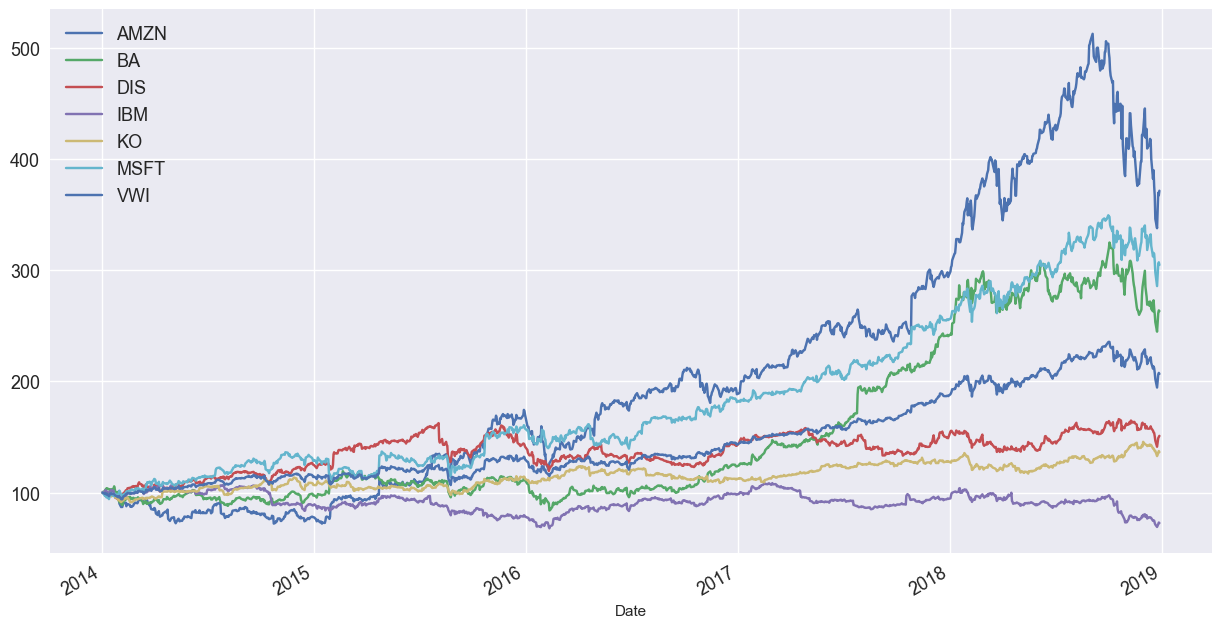

In [77]:
norm.iloc[:, [0, 1, 2, 3, 4, 5, 8]].plot(figsize = (15, 8 ), fontsize = 13)
plt.legend(fontsize = 13)
plt.show()

In [78]:
norm.head()

Ticker,AMZN,BA,DIS,IBM,KO,MSFT,PWI,EWI,VWI
Date,,,,,,,,,
2014-01-02,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00
2014-01-03,99.62,100.70,99.79,100.60,99.51,99.33,100.24,99.92,99.78
2014-01-06,98.91,101.27,99.41,100.25,99.04,97.23,100.00,99.35,98.86
2014-01-07,100.02,102.81,100.09,102.25,99.34,97.98,101.34,100.41,99.78
2014-01-08,100.99,103.04,98.62,101.32,98.23,96.23,100.69,99.72,98.57


## Comparison of weighting methods

In [79]:
norm.head()

Ticker,AMZN,BA,DIS,IBM,KO,MSFT,PWI,EWI,VWI
Date,,,,,,,,,
2014-01-02,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00
2014-01-03,99.62,100.70,99.79,100.60,99.51,99.33,100.24,99.92,99.78
2014-01-06,98.91,101.27,99.41,100.25,99.04,97.23,100.00,99.35,98.86
2014-01-07,100.02,102.81,100.09,102.25,99.34,97.98,101.34,100.41,99.78
2014-01-08,100.99,103.04,98.62,101.32,98.23,96.23,100.69,99.72,98.57


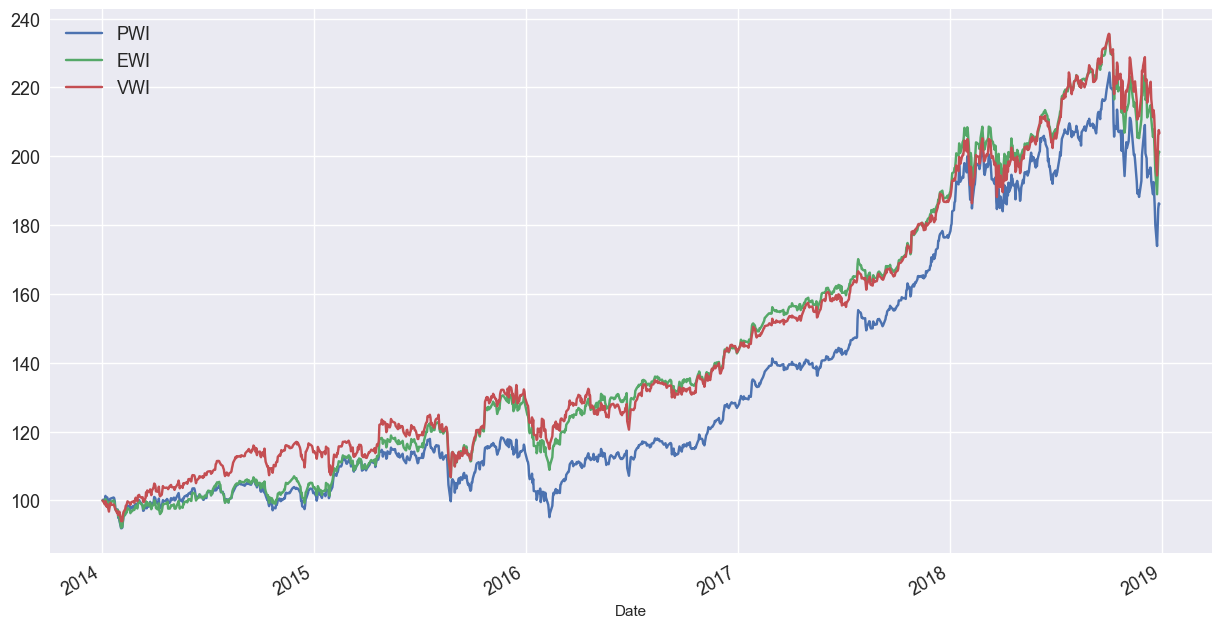

In [80]:
norm.iloc[:, -3:].plot(figsize = (15, 8 ), fontsize = 13)
plt.legend(fontsize = 13)
plt.show()

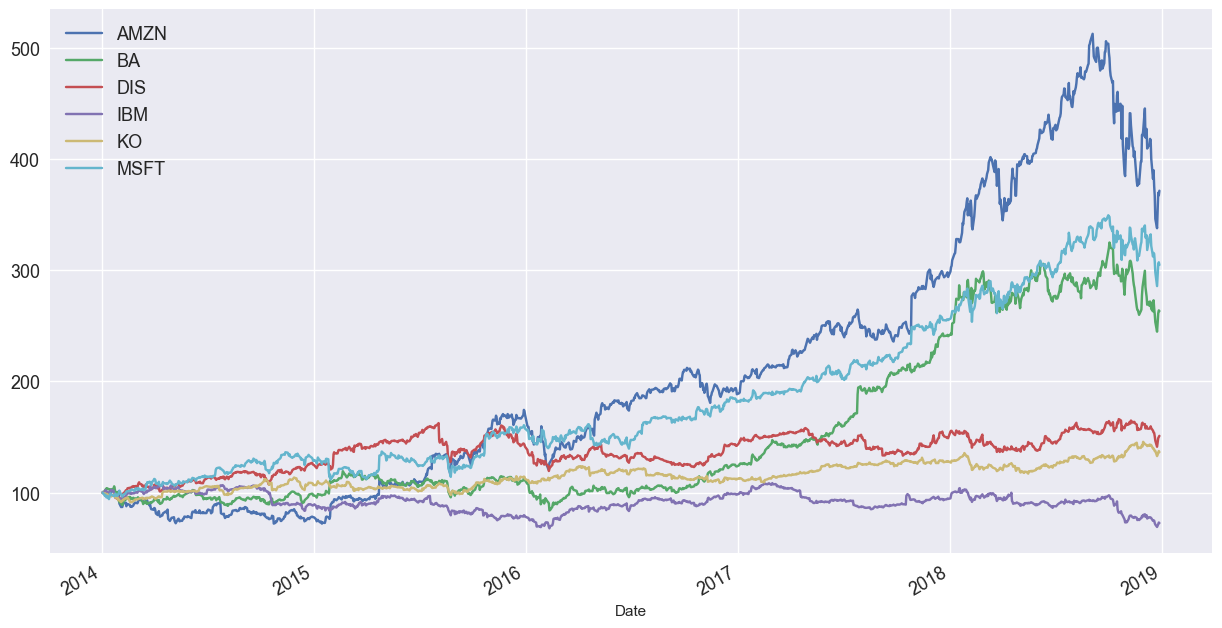

In [81]:
norm.iloc[:, :-3].plot(figsize = (15, 8 ), fontsize = 13)
plt.legend(fontsize = 13)
plt.show()

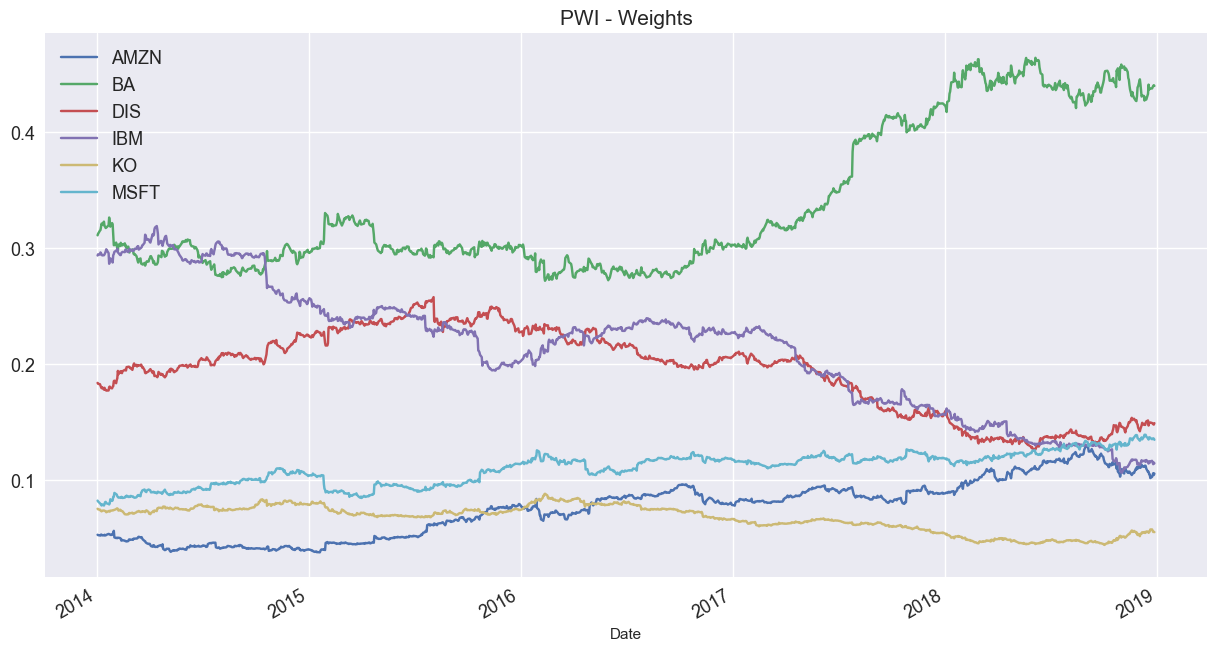

In [82]:
weights_PWI.plot(figsize = (15, 8), fontsize = 13)
plt.legend(fontsize = 13)
plt.title("PWI - Weights", fontsize = 15)
plt.show()

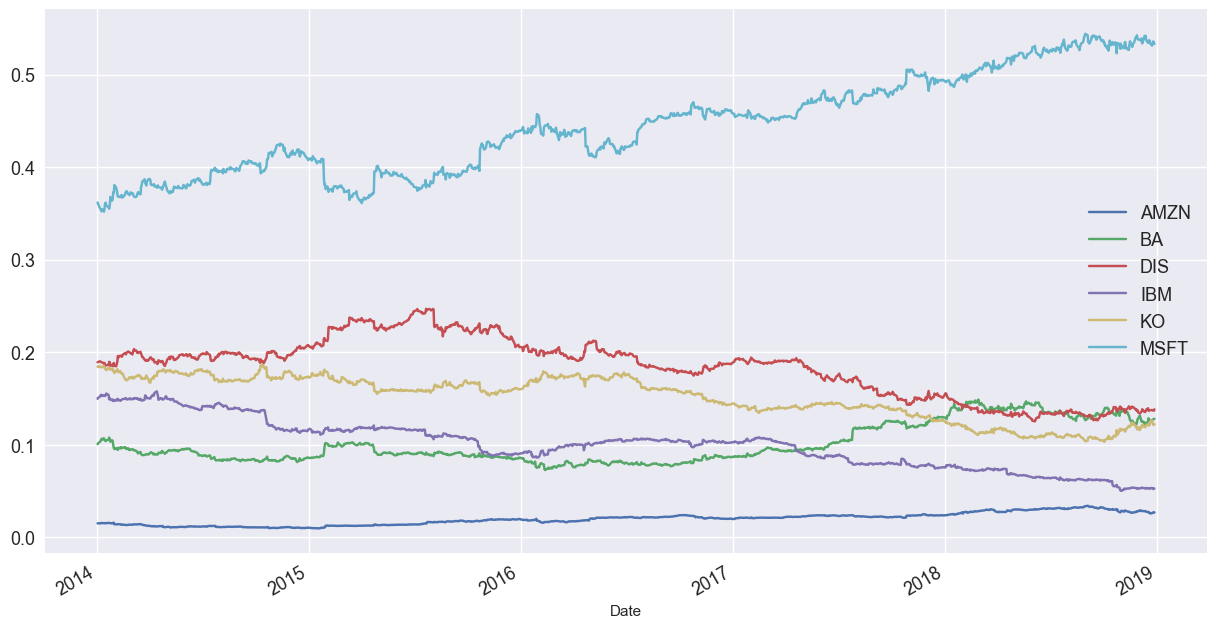

In [83]:
weights_vwi.plot(figsize = (15, 8), fontsize = 13)
plt.legend(fontsize = 13)
plt.show()

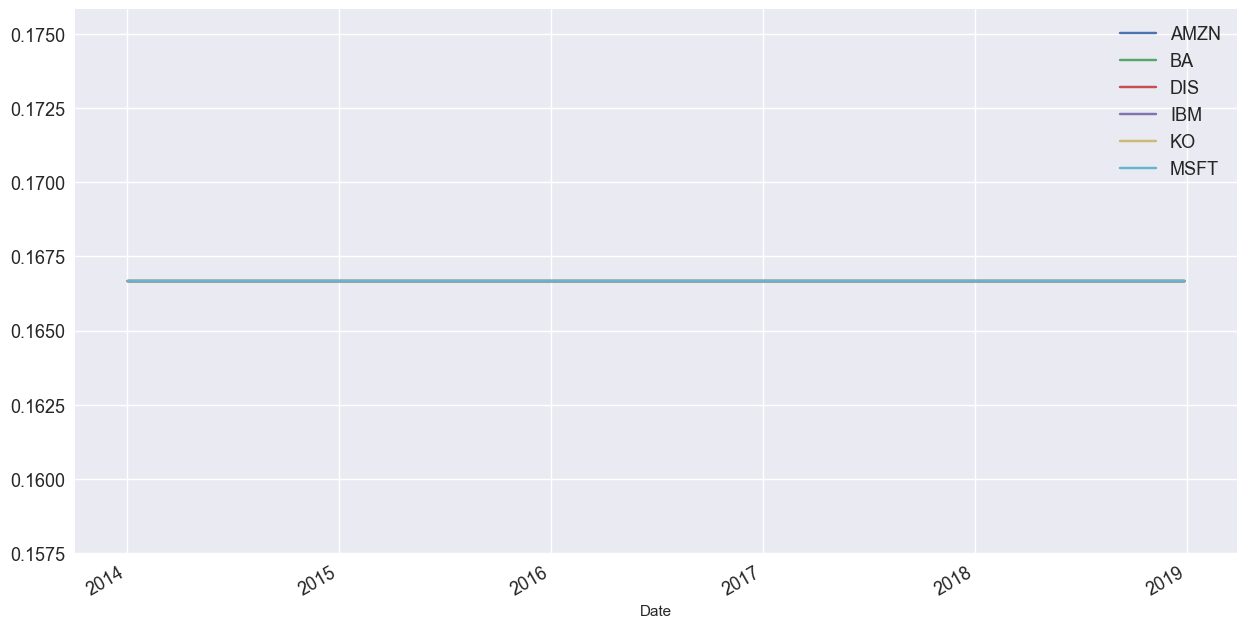

In [84]:
weights_EWI.plot(figsize = (15, 8), fontsize = 13)
plt.legend(fontsize = 13)
plt.show()

In [85]:
summary = norm.pct_change().dropna().agg(["mean", "std"]).T

In [86]:
summary.head()

,mean,std
Ticker,,
AMZN,0.00,0.02
BA,0.00,0.01
DIS,0.00,0.01
IBM,-0.00,0.01
KO,0.00,0.01


In [87]:
summary.columns = ["Return", "Risk"]

In [88]:
summary["Return"] = summary["Return"]*252
summary["Risk"] = summary["Risk"] * np.sqrt(252)

In [89]:
summary

,Return,Risk
Ticker,,
AMZN,0.31,0.31
BA,0.22,0.23
DIS,0.10,0.19
IBM,-0.04,0.20
KO,0.07,0.14
MSFT,0.25,0.23
PWI,0.14,0.16
EWI,0.15,0.15
VWI,0.16,0.16


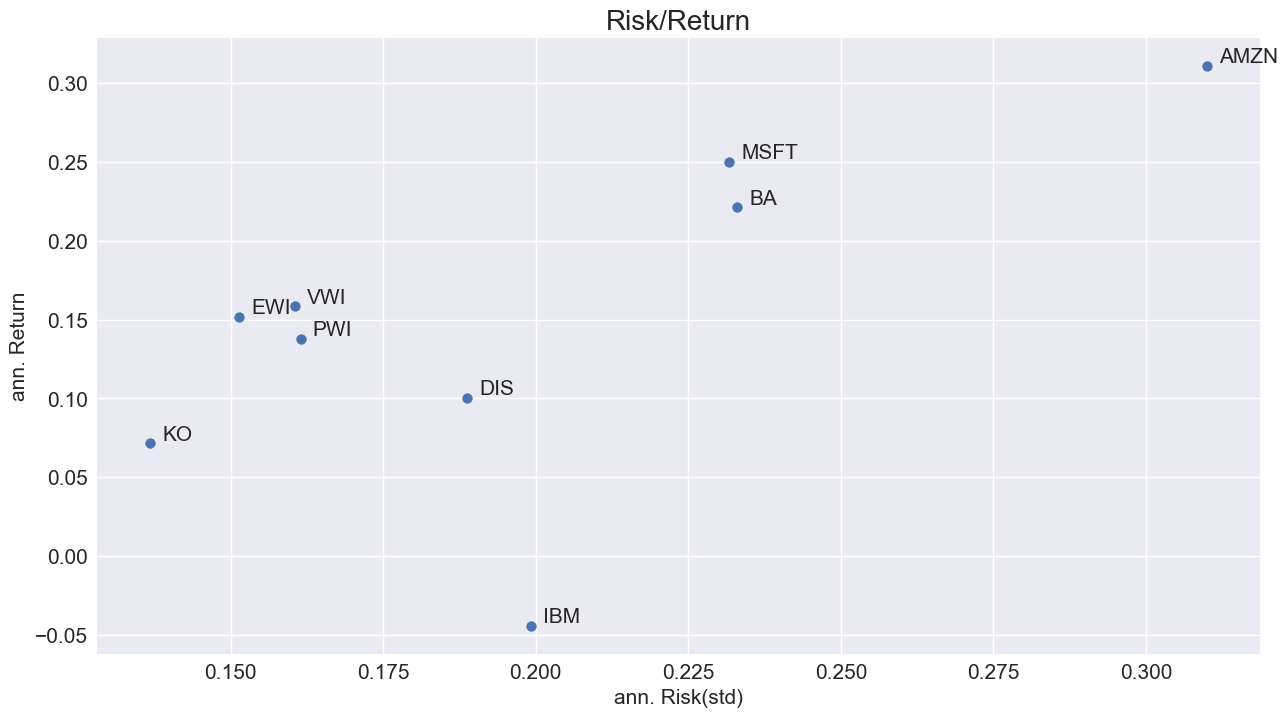

In [90]:
summary.plot(kind = "scatter", x = "Risk", y = "Return", figsize = (15, 8), s = 50, fontsize = 15)
for i in summary.index:
    plt.annotate(i, xy=(summary.loc[i, "Risk"]+0.002, summary.loc[i, "Return"]+0.002), size = 15)
plt.xlabel("ann. Risk(std)", fontsize = 15)
plt.ylabel("ann. Return", fontsize = 15)
plt.title("Risk/Return", fontsize = 20)
plt.show()

## Price Index vs. Performance/Total Return Index

In [91]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")
pd.options.display.float_format = '{:.2f}'.format

In [92]:
stocks = pd.read_csv("index_stocks.csv", header = [0,1], index_col = [0], parse_dates = [0])

In [ ]:
stocks.head()

Price      Close                                  High                      \
Ticker      AMZN     BA   DIS    IBM    KO  MSFT  AMZN     BA   DIS    IBM   
Date                                                                         
2014-01-02 19.90 116.81 69.04 110.28 28.31 30.94 19.97 117.30 69.25 111.39   
2014-01-03 19.82 117.62 68.90 110.94 28.17 30.73 20.14 118.37 69.43 111.36   
2014-01-06 19.68 118.30 68.63 110.55 28.04 30.08 19.85 119.45 69.56 111.36   
2014-01-07 19.90 120.09 69.10 112.76 28.12 30.32 19.92 120.59 69.43 113.14   
2014-01-08 20.10 120.35 68.09 111.73 27.81 29.77 20.15 120.85 69.05 112.59   

Price       ...  Open                       Volume                     \
Ticker      ...   DIS    IBM    KO  MSFT      AMZN       BA       DIS   
Date        ...                                                         
2014-01-02  ... 68.83 111.27 28.63 31.10  42756000  3366700   5200900   
2014-01-03  ... 69.07 110.45 28.33 30.97  44204000  3177400   4060700   
2014-01-06  ... 69.28 111.24 28.19 30.68  63412000  4196500   6816200   
2014-01-07  ... 68.91 110.79 28.19 30.25  38320000  4238500   4494900   
2014-01-08  ... 68.91 112.53 28.16 29.97  46330000  4236100  10900300   

Price                                    
Ticker          IBM        KO      MSFT  
Date                                     
2014-01-02  4755639  12698600  30632200  
2014-01-03  4250107  10403400  31134800  
2014-01-06  4254919  11036300  43603700  
2014-01-07  6205186  11872300  35802800  
2014-01-08  4815470  15339600  59971700  

[5 rows x 30 columns]

In [95]:
adjclose=stocks["Adj Close"].copy()

KeyError: 'Adj Close'

In [96]:
total_return = adj_close.pct_change().dropna()

NameError: name 'adj_close' is not defined

In [97]:
# Extract 'Close' prices for all tickers (since no 'Adj Close' exists)
close_prices = stocks["Close"].copy()

# Calculate daily percentage change (total returns)
total_return = close_prices.pct_change().dropna()

# Quick checks
print(close_prices.head())
print(total_return.head())


Ticker      AMZN     BA   DIS    IBM    KO  MSFT
Date                                            
2014-01-02 19.90 116.81 69.04 110.28 28.31 30.94
2014-01-03 19.82 117.62 68.90 110.94 28.17 30.73
2014-01-06 19.68 118.30 68.63 110.55 28.04 30.08
2014-01-07 19.90 120.09 69.10 112.76 28.12 30.32
2014-01-08 20.10 120.35 68.09 111.73 27.81 29.77
Ticker      AMZN   BA   DIS   IBM    KO  MSFT
Date                                         
2014-01-03 -0.00 0.01 -0.00  0.01 -0.00 -0.01
2014-01-06 -0.01 0.01 -0.00 -0.00 -0.00 -0.02
2014-01-07  0.01 0.02  0.01  0.02  0.00  0.01
2014-01-08  0.01 0.00 -0.01 -0.01 -0.01 -0.02
2014-01-09 -0.00 0.01 -0.00 -0.00 -0.01 -0.01


In [98]:
total_return.head()

Ticker,AMZN,BA,DIS,IBM,KO,MSFT
Date,,,,,,
2014-01-03,-0.00,0.01,-0.00,0.01,-0.00,-0.01
2014-01-06,-0.01,0.01,-0.00,-0.00,-0.00,-0.02
2014-01-07,0.01,0.02,0.01,0.02,0.00,0.01
2014-01-08,0.01,0.00,-0.01,-0.01,-0.01,-0.02
2014-01-09,-0.00,0.01,-0.00,-0.00,-0.01,-0.01


In [99]:
close = stocks["Close"].copy()

In [100]:
weights = close.div(close.sum(axis = 1), axis = "index")

In [101]:
weights.head()

Ticker,AMZN,BA,DIS,IBM,KO,MSFT
Date,,,,,,
2014-01-02,0.05,0.31,0.18,0.29,0.08,0.08
2014-01-03,0.05,0.31,0.18,0.29,0.07,0.08
2014-01-06,0.05,0.32,0.18,0.29,0.07,0.08
2014-01-07,0.05,0.32,0.18,0.30,0.07,0.08
2014-01-08,0.05,0.32,0.18,0.30,0.07,0.08


In [102]:
norm["PWI_perf"] = 100
norm.head()

Ticker,AMZN,BA,DIS,IBM,KO,MSFT,PWI,EWI,VWI,PWI_perf
Date,,,,,,,,,,
2014-01-02,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100
2014-01-03,99.62,100.70,99.79,100.60,99.51,99.33,100.24,99.92,99.78,100
2014-01-06,98.91,101.27,99.41,100.25,99.04,97.23,100.00,99.35,98.86,100
2014-01-07,100.02,102.81,100.09,102.25,99.34,97.98,101.34,100.41,99.78,100
2014-01-08,100.99,103.04,98.62,101.32,98.23,96.23,100.69,99.72,98.57,100


In [103]:
norm.iloc[1:, -1] = total_return.mul(weights.shift().dropna()).sum(axis = 1).add(1).cumprod().mul(100)

C:\Users\arsh\AppData\Local\Temp\ipykernel_9256\2162611693.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[100.24062369 100.00348204 101.33779529 ... 184.71465125 186.33617821
 186.14837775]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  norm.iloc[1:, -1] = total_return.mul(weights.shift().dropna()).sum(axis = 1).add(1).cumprod().mul(100)


In [104]:
norm

Ticker,AMZN,BA,DIS,IBM,KO,MSFT,PWI,EWI,VWI,PWI_perf
Date,,,,,,,,,,
2014-01-02,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00
2014-01-03,99.62,100.70,99.79,100.60,99.51,99.33,100.24,99.92,99.78,100.24
2014-01-06,98.91,101.27,99.41,100.25,99.04,97.23,100.00,99.35,98.86,100.00
2014-01-07,100.02,102.81,100.09,102.25,99.34,97.98,101.34,100.41,99.78,101.34
2014-01-08,100.99,103.04,98.62,101.32,98.23,96.23,100.69,99.72,98.57,100.69
...,...,...,...,...,...,...,...,...,...,...
2018-12-21,346.12,253.35,146.68,71.29,137.48,298.10,180.09,195.55,202.16,180.09
2018-12-24,337.70,244.70,141.24,69.12,132.82,285.66,173.94,188.98,194.45,173.94
2018-12-26,369.60,261.15,148.95,71.58,135.65,305.17,184.71,199.73,205.99,184.71


In [105]:
summary = norm.pct_change().dropna().agg(["mean", "std"]).T

In [106]:
summary["mean"] = summary["mean"]*252
summary["std"] = summary["std"] * np.sqrt(252)

In [107]:
summary

,mean,std
Ticker,,
AMZN,0.31,0.31
BA,0.22,0.23
DIS,0.10,0.19
IBM,-0.04,0.20
KO,0.07,0.14
MSFT,0.25,0.23
PWI,0.14,0.16
EWI,0.15,0.15
VWI,0.16,0.16


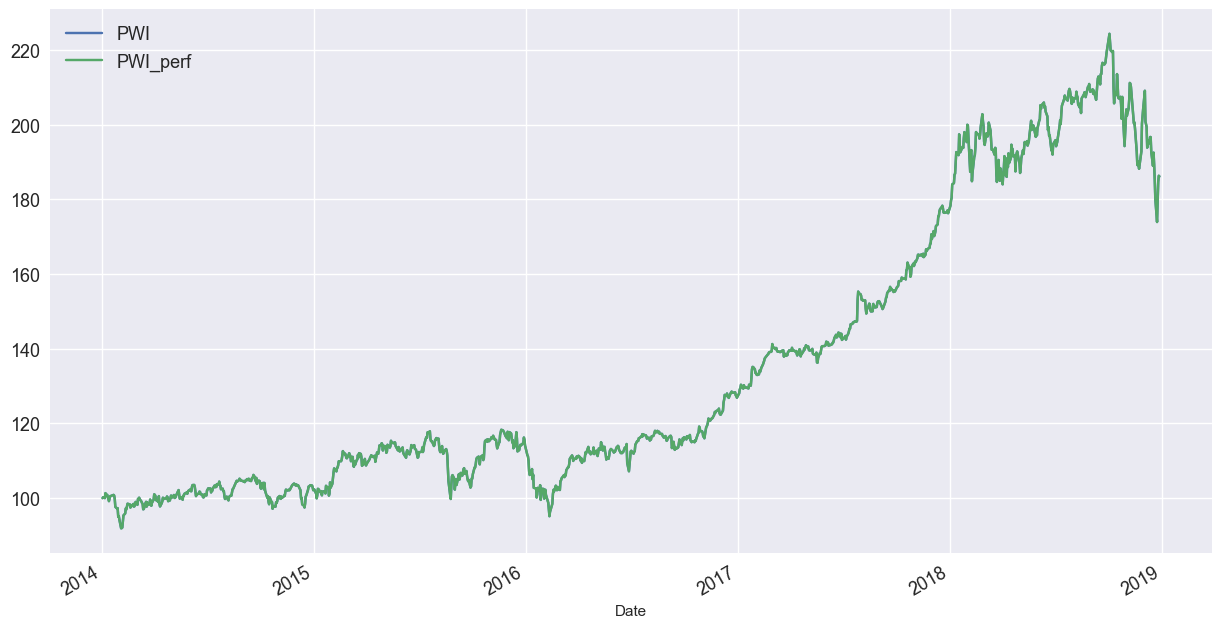

In [108]:
norm.iloc[:, [6, 9]].plot(figsize = (15, 8 ), fontsize = 13)
plt.legend(fontsize = 13)
plt.show()